<a href="https://colab.research.google.com/github/meenakshi16rp/02-Vanilla-Autoencoder-FashionMNIST/blob/main/FASHION_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [3]:
transform = transforms.ToTensor()

In [4]:
import matplotlib.pyplot as plt

In [5]:
train_dataset= datasets.FashionMNIST(
    root="./data",
    train= True,
    download= True,
    transform= transform
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 20.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 308kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.47MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.0MB/s]


In [6]:
test_dataset = datasets.FashionMNIST(
    root="./data",
    train = False,
    download= True,
    transform= transform
)

In [7]:
batch_size = 64

In [8]:
train_loader= DataLoader(
    train_dataset,
    batch_size= batch_size,
    shuffle= True
)

In [9]:
test_loader= DataLoader(
    test_dataset,
    batch_size= batch_size,
    shuffle= True
)

In [10]:
print("Training Images :", len(train_dataset))
print("Testing Images  :", len(test_dataset))

Training Images : 60000
Testing Images  : 10000


In [11]:
images, labels = next(iter(train_loader))

In [12]:
print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [14]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

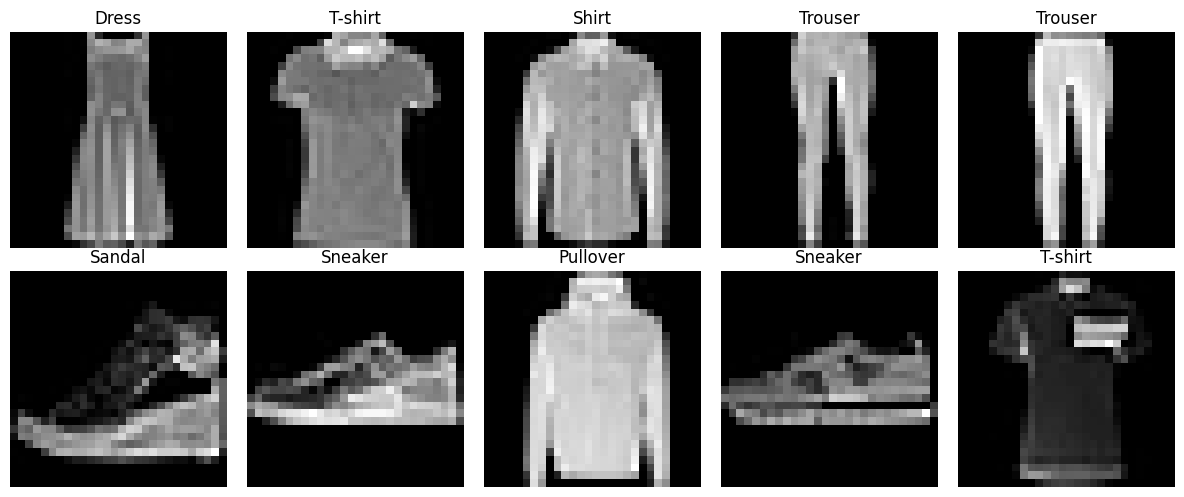

In [15]:
plt.figure(figsize=(12,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    plt.title(class_names[labels[i]])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [17]:
print(images)

tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..

In [35]:
class Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784,256),
            nn.ReLU(),

            nn.Linear(256,128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.ReLU(),

            nn.Linear(64,32)
        )

    def forward(self, x):
        return self.encoder(x)

In [37]:
class Decoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.decoder = nn.Sequential(

            nn.Linear(32,64),
            nn.ReLU(),

            nn.Linear(64,128),
            nn.ReLU(),

            nn.Linear(128,256),
            nn.ReLU(),

            nn.Linear(256,784),

            nn.Sigmoid()
        )

    def forward(self,x):
        return self.decoder(x)

In [38]:
class Autoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = Encoder()

        self.decoder = Decoder()

    def forward(self,x):

        latent = self.encoder(x)

        reconstructed = self.decoder(latent)

        return reconstructed

In [39]:
model = Autoencoder()

print(model)

Autoencoder(
  (encoder): Encoder(
    (encoder): Sequential(
      (0): Linear(in_features=784, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): ReLU()
      (6): Linear(in_features=64, out_features=32, bias=True)
    )
  )
  (decoder): Decoder(
    (decoder): Sequential(
      (0): Linear(in_features=32, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=256, bias=True)
      (5): ReLU()
      (6): Linear(in_features=256, out_features=784, bias=True)
      (7): Sigmoid()
    )
  )
)


In [40]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total Parameters:", total_params)
print("Trainable Parameters:", trainable_params)

Total Parameters: 489136
Trainable Parameters: 489136


In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

cpu


In [42]:
criterion = nn.MSELoss()

In [43]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [44]:
epochs = 10

In [45]:
losses = []


In [46]:
for epoch in range(epochs):

    model.train()

    epoch_loss = 0

    for images, _ in train_loader:

        # Move to GPU (if available)
        images = images.to(device)

        # Flatten images
        images = images.view(images.size(0), -1)

        # Forward Pass
        outputs = model(images)

        # Compute Loss
        loss = criterion(outputs, images)

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}]  Loss: {avg_loss:.4f}")

Epoch [1/10]  Loss: 0.0352
Epoch [2/10]  Loss: 0.0218
Epoch [3/10]  Loss: 0.0191
Epoch [4/10]  Loss: 0.0174
Epoch [5/10]  Loss: 0.0162
Epoch [6/10]  Loss: 0.0152
Epoch [7/10]  Loss: 0.0145
Epoch [8/10]  Loss: 0.0139
Epoch [9/10]  Loss: 0.0133
Epoch [10/10]  Loss: 0.0128


In [47]:
torch.save(model.state_dict(), "fashion_autoencoder.pth")

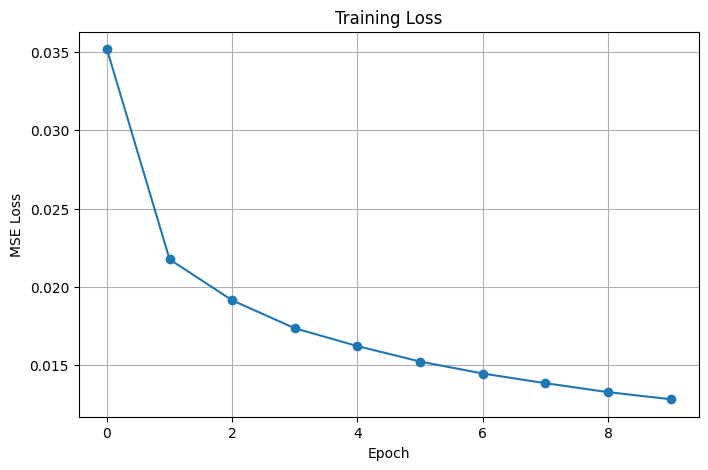

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(losses, marker='o')

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.grid(True)

plt.savefig("loss_curve.png", dpi=300)

plt.show()

In [49]:
model.eval()

Autoencoder(
  (encoder): Encoder(
    (encoder): Sequential(
      (0): Linear(in_features=784, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): ReLU()
      (6): Linear(in_features=64, out_features=32, bias=True)
    )
  )
  (decoder): Decoder(
    (decoder): Sequential(
      (0): Linear(in_features=32, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=256, bias=True)
      (5): ReLU()
      (6): Linear(in_features=256, out_features=784, bias=True)
      (7): Sigmoid()
    )
  )
)

In [50]:
images, labels = next(iter(test_loader))

original_images = images.clone()

images = images.view(images.size(0), -1).to(device)

In [51]:
with torch.no_grad():

    reconstructed = model(images)

In [52]:
reconstructed = reconstructed.cpu().view(-1,1,28,28)

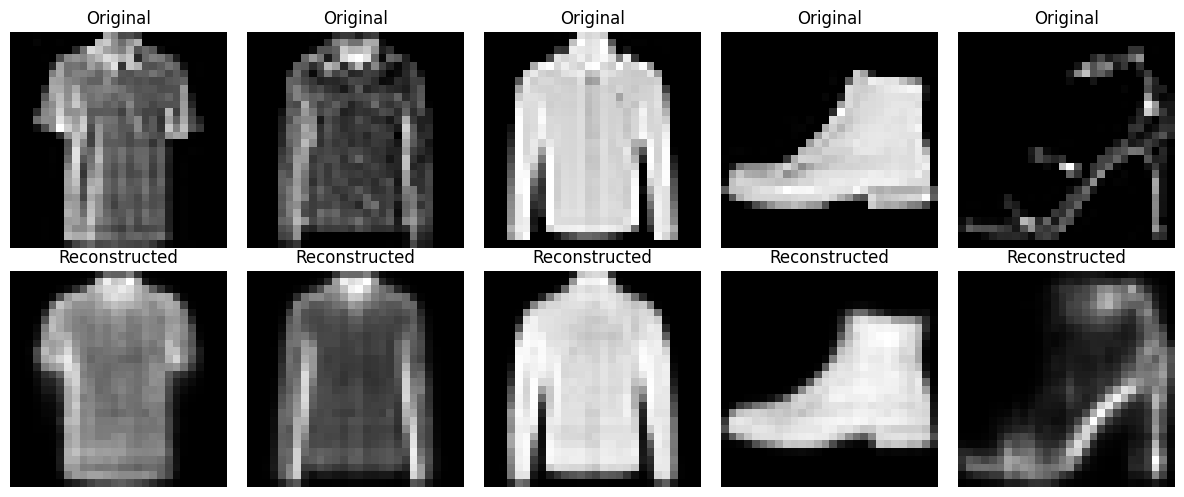

In [53]:
import matplotlib.pyplot as plt

n = 5

plt.figure(figsize=(12,5))

for i in range(n):

    # Original
    plt.subplot(2,n,i+1)

    plt.imshow(original_images[i].squeeze(), cmap="gray")

    plt.title("Original")

    plt.axis("off")

    # Reconstruction
    plt.subplot(2,n,i+n+1)

    plt.imshow(reconstructed[i].squeeze(), cmap="gray")

    plt.title("Reconstructed")

    plt.axis("off")

plt.tight_layout()

plt.savefig("fashion_reconstruction.png", dpi=300)

plt.show()

In [56]:
error = torch.abs(original_images - reconstructed)
print(error)

tensor([[[[5.5497e-06, 7.0682e-06, 1.1865e-05,  ..., 2.7424e-05,
           1.3241e-05, 7.0739e-06],
          [1.3022e-05, 1.1921e-05, 2.8075e-05,  ..., 2.0173e-06,
           2.7937e-06, 1.3002e-05],
          [9.2320e-06, 1.9704e-05, 2.8844e-05,  ..., 4.5069e-07,
           1.4285e-06, 6.2169e-06],
          ...,
          [1.5001e-04, 1.3130e-04, 8.9226e-05,  ..., 3.3308e-05,
           1.9218e-05, 5.0794e-06],
          [2.2621e-04, 5.9597e-05, 3.8876e-05,  ..., 1.4069e-05,
           6.9958e-06, 7.4858e-06],
          [1.7717e-05, 5.8301e-05, 8.1280e-05,  ..., 2.2498e-05,
           9.9158e-06, 1.3322e-05]]],


        [[[4.3165e-05, 4.5381e-05, 8.7510e-05,  ..., 9.1659e-05,
           4.3777e-05, 6.2260e-05],
          [5.4073e-05, 7.0582e-05, 7.4326e-05,  ..., 7.2499e-05,
           5.2119e-05, 7.2348e-05],
          [9.6247e-05, 5.8867e-05, 1.2019e-04,  ..., 1.4152e-05,
           2.1945e-05, 6.2691e-05],
          ...,
          [9.1712e-04, 2.0179e-03, 6.3103e-03,  ..., 3.73

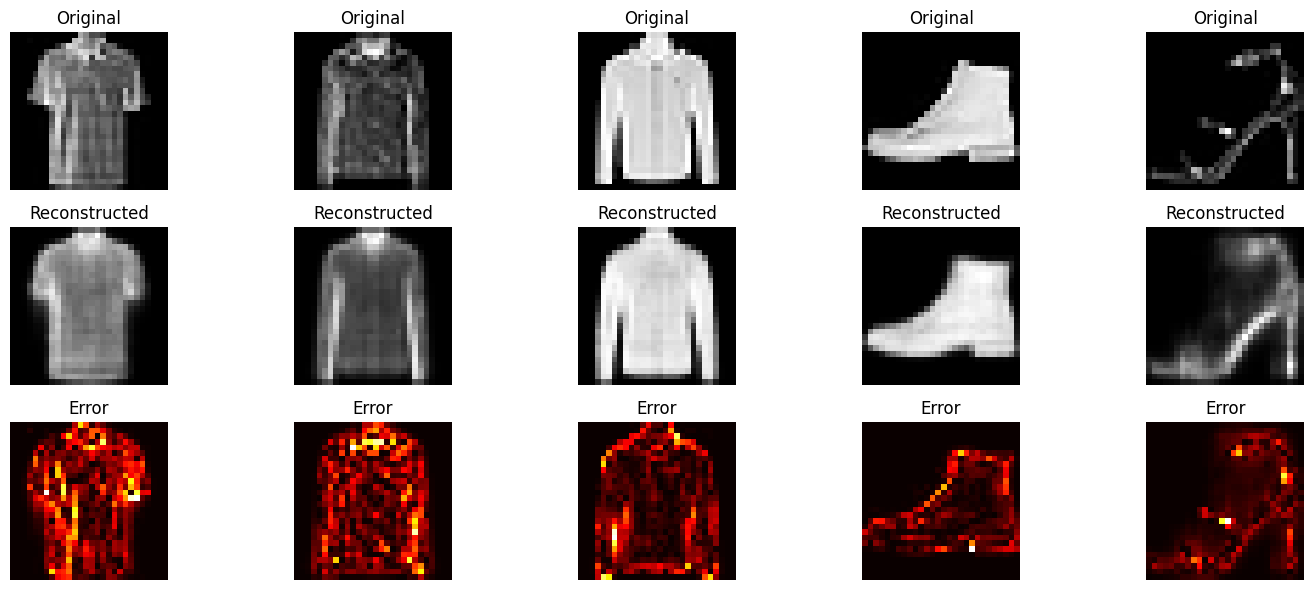

In [55]:
n = 5

plt.figure(figsize=(15,6))

for i in range(n):

    # Original
    plt.subplot(3,n,i+1)

    plt.imshow(original_images[i].squeeze(), cmap="gray")

    plt.title("Original")

    plt.axis("off")

    # Reconstruction
    plt.subplot(3,n,i+n+1)

    plt.imshow(reconstructed[i].squeeze(), cmap="gray")

    plt.title("Reconstructed")

    plt.axis("off")

    # Error
    plt.subplot(3,n,i+2*n+1)

    plt.imshow(error[i].squeeze(), cmap="hot")

    plt.title("Error")

    plt.axis("off")

plt.tight_layout()

plt.savefig("fashion_reconstruction_error.png", dpi=300)

plt.show()